In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pearsonr, probplot
import numpy as np

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df.info()
df.describe()
df.isna().sum()
df["isBestSeller"].value_counts()
df["category"].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


296

In [4]:
crosstab = pd.crosstab(df["category"], df["isBestSeller"])
crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [5]:
best_seller_rate = (
    pd.crosstab(df["category"], df["isBestSeller"], normalize="index")[True]
    .sort_values(ascending=False)
)
best_seller_rate.head(10)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Name: True, dtype: float64

In [17]:
from scipy.stats import chi2_contingency
import numpy as np

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(crosstab)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 36540.20270061387
p-value: 0.0
Degrees of freedom: 295


In [18]:
# Cramér's V
n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


In [19]:
if p_value < 0.05:
    print("There is a statistically significant relationship between category and best-seller status.")
else:
    print("There is no statistically significant relationship between category and best-seller status.")

if cramers_v < 0.1:
    print("The association is very weak.")
elif cramers_v < 0.3:
    print("The association is weak.")
elif cramers_v < 0.5:
    print("The association is moderate.")
else:
    print("The association is strong.")

There is a statistically significant relationship between category and best-seller status.
The association is weak.


In [20]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df[
    (df["price"] >= Q1 - 1.5 * IQR) &
    (df["price"] <= Q3 + 1.5 * IQR)
]

In [21]:
top_20_categories = df_no_outliers["category"].value_counts().head(20).index
top_10_categories = df_no_outliers["category"].value_counts().head(10).index

df_top_20 = df_no_outliers[df_no_outliers["category"].isin(top_20_categories)]
df_top_10 = df_no_outliers[df_no_outliers["category"].isin(top_10_categories)]

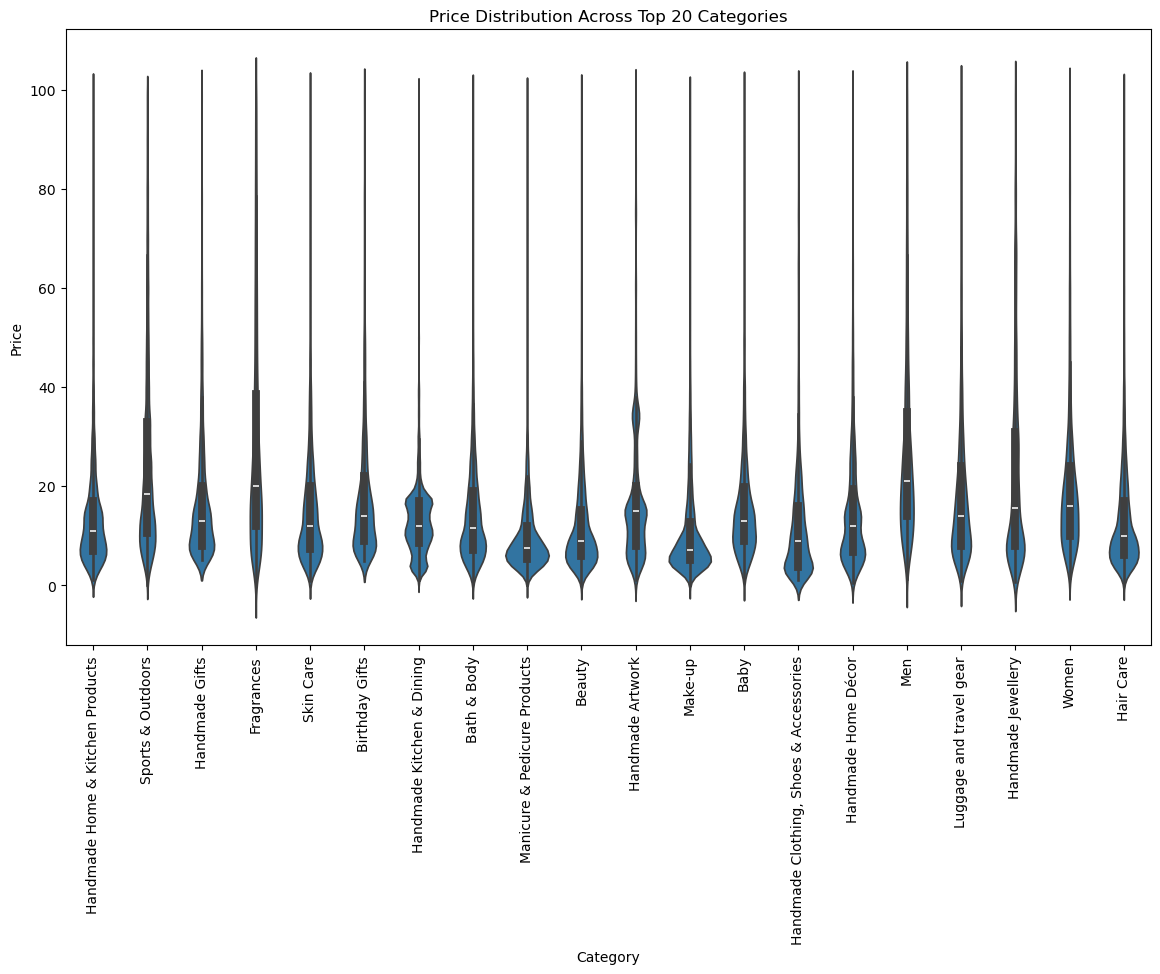

In [22]:
plt.figure(figsize=(14, 8))

sns.violinplot(
    data=df_top_20,
    x="category",
    y="price"
)

plt.xticks(rotation=90)
plt.title("Price Distribution Across Top 20 Categories")
plt.xlabel("Category")
plt.ylabel("Price")
plt.show()

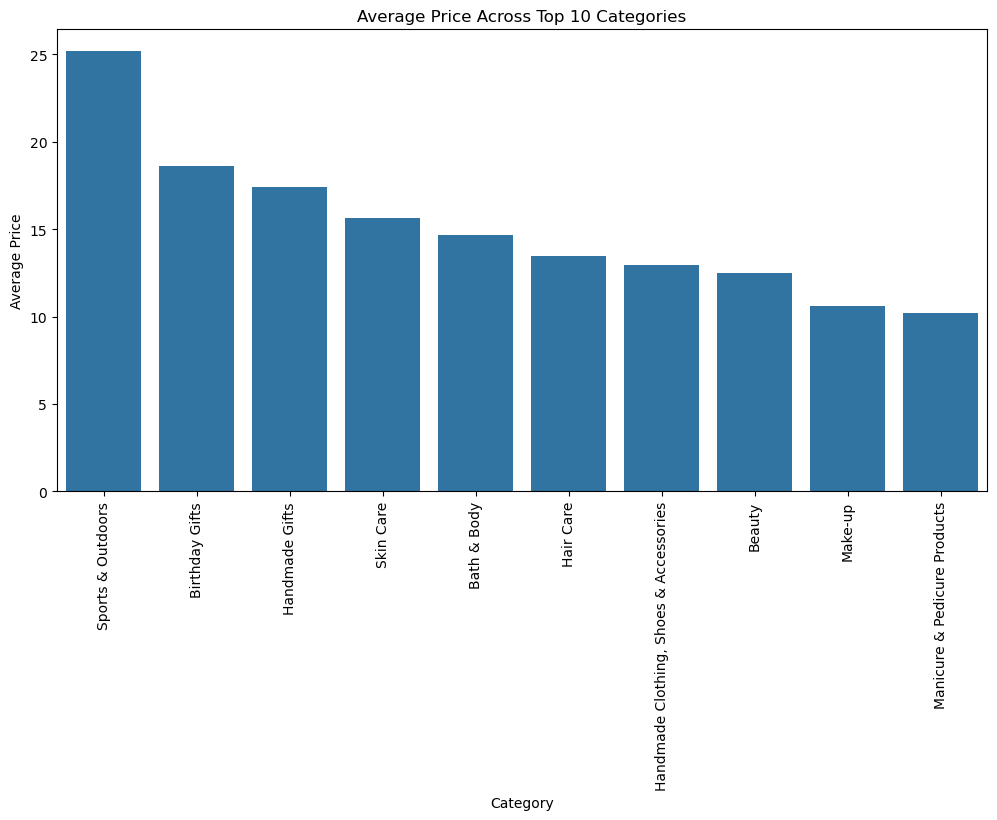

In [23]:
avg_price_top_10 = (
    df_top_10
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_price_top_10.index,
    y=avg_price_top_10.values
)

plt.xticks(rotation=90)
plt.title("Average Price Across Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

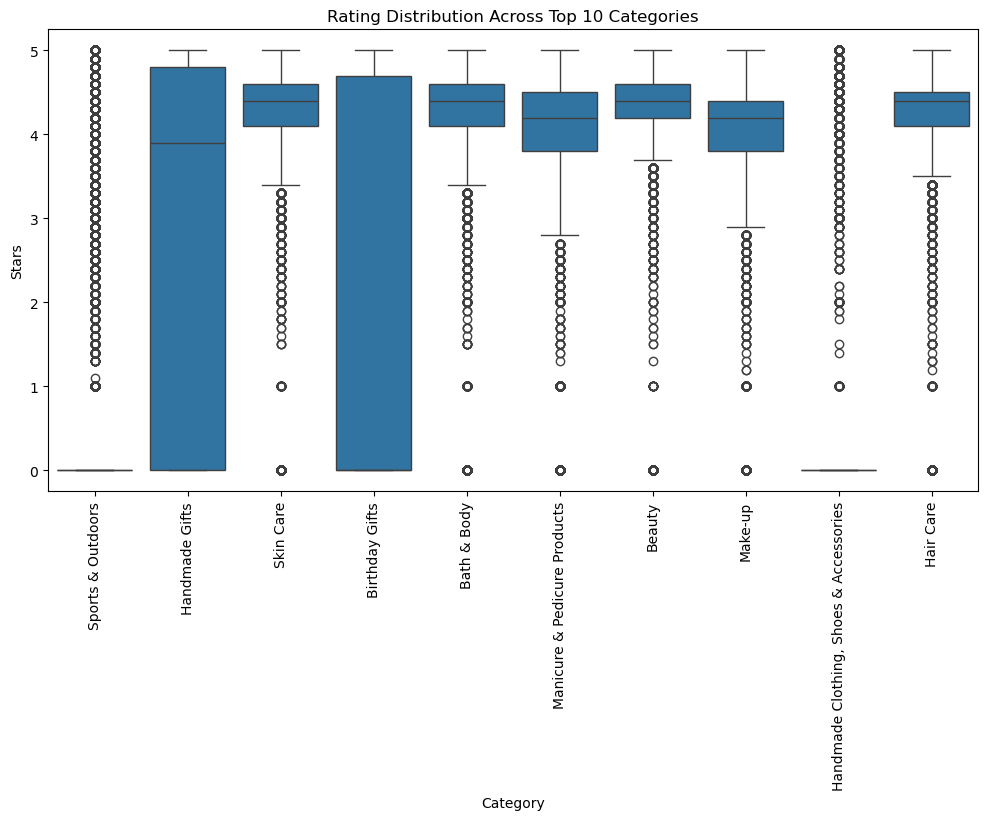

In [24]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_10,
    x="category",
    y="stars"
)

plt.xticks(rotation=90)
plt.title("Rating Distribution Across Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Stars")
plt.show()

In [25]:
df_no_outliers[["price", "stars"]].corr()

,price,stars
price,1.000000,-0.077673
stars,-0.077673,1.000000


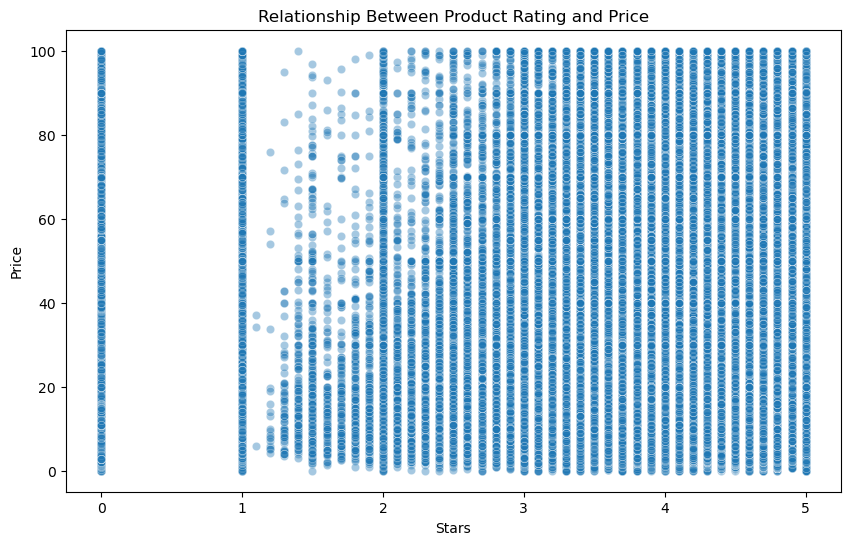

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_no_outliers,
    x="stars",
    y="price",
    alpha=0.4
)

plt.title("Relationship Between Product Rating and Price")
plt.xlabel("Stars")
plt.ylabel("Price")
plt.show()

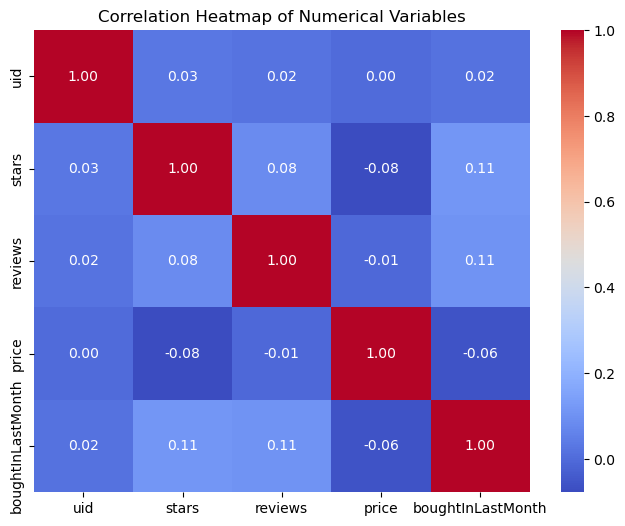

In [27]:
numeric_df = df_no_outliers.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

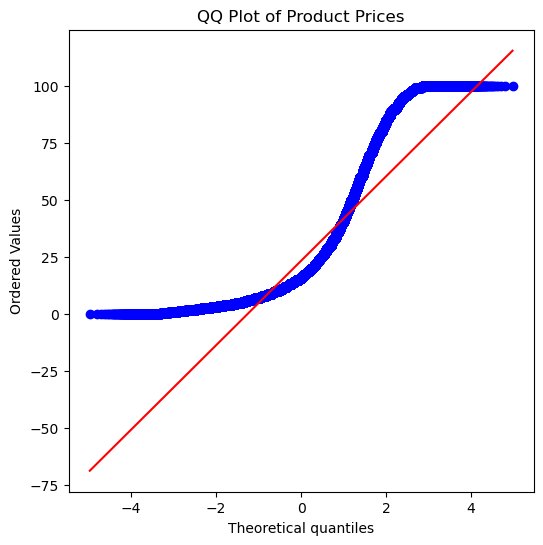

In [28]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))

stats.probplot(df_no_outliers["price"], dist="norm", plot=plt)

plt.title("QQ Plot of Product Prices")
plt.show()

## Conclusion

The analysis shows that best-seller status is not evenly distributed across product categories. Categories such as Grocery, Smart Home Security & Lighting, and Health & Personal Care have the highest proportion of best-seller products, with around 5.8% of products marked as best sellers. This suggests that fast-moving consumer goods and practical household-related categories may have stronger repeat demand and higher customer engagement.

The Chi-square test indicates that best-seller status and product category are likely related rather than independent. However, Cramér’s V is approximately 0.12, which means the relationship is weak. In business terms, category matters, but it is not the only factor that determines whether a product becomes a best seller. Brand, price, reviews, product visibility, and customer need are also likely important.

After removing price outliers, most product prices are below £100. The violin and bar plots show that price distributions vary noticeably by category. Among all categories, Desktop PCs have the highest median price, while Motherboards have the highest average price. This suggests that electronics and computer-related categories tend to command higher prices than everyday consumer categories.

For the top 10 most common categories, Sports & Outdoors has the highest average price, at around £25.17. Beauty, Make-up, Hair Care, and Skin Care tend to have lower average prices, showing that high-volume categories are not necessarily high-price categories.

The ratings analysis shows that customer ratings are generally clustered toward the higher end, but some categories contain many products with 0-star values, which may represent unrated products rather than genuinely poor ratings. Because of this, ratings should be interpreted carefully. Among all categories, Computer Memory has one of the highest median ratings, around 4.7 stars.

The correlation between price and stars is approximately -0.078, which is very close to zero. This means there is no meaningful linear relationship between product price and customer rating. Higher-priced products are not necessarily rated better, and lower-priced products are not necessarily rated worse.

The scatter plot supports this conclusion because the points do not show a strong upward or downward pattern. The QQ plot suggests that product prices are not normally distributed; instead, prices are right-skewed, with many lower-priced products and fewer high-priced products.

Overall, the business insight is that product category has some influence on best-seller status, price levels, and ratings, but it does not fully explain product performance. For pricing and strategy decisions, Amazon sellers should compare products within the same category, focus on customer demand and review quality, and avoid assuming that higher prices automatically lead to higher ratings.